In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../../..")))

from src.data_postprocessing import obtain_shoreline

In [2]:
# Execute this cell to make sure 
# that external modules are reloaded
%load_ext autoreload
%autoreload 2

In [3]:
data = {
    # "train": {
    #     "images": [],
    #     "ground_truth": [],
    #     "predicted_mask": []
    # },
    # "validation": {
    #     "images": [],
    #     "ground_truth": [],
    #     "predicted_mask": []
    # },
    "test": {
        "images": [],
        "ground_truth": [],
        "predicted_mask": []
    }
}

# Open the image file
base_path = os.path.abspath(os.path.join(os.getcwd(), "../../../data/SCLabels_oblique_prediction_deeplab_256x1024/"))

# sub_dirs = ["train", "validation", "test"]
sub_dirs = ["test"]

for sub_dir in sub_dirs:
    for file in os.listdir(os.path.join(base_path, "images", sub_dir)):
        if file.endswith(".jpg"):
            path = os.path.join(base_path, "images", sub_dir, file)
            data[sub_dir]["images"].append(path)

            file = file.replace("image.jpg", "mask.png")
            path = os.path.join(base_path, "masks", sub_dir, file)
            data[sub_dir]["ground_truth"].append(path)

            # file = file.replace("mask.png", "pred.png")
            path = os.path.join(base_path, "predicted_mask", sub_dir, file)
            data[sub_dir]["predicted_mask"].append(path)

print("Data loaded")

Data loaded


In [4]:
# Create a KDTree for the Ground Truth coordinates
from scipy.spatial import cKDTree

def compute_distance(mask_pred, mask_gt):
    coords_pred = np.column_stack(np.where(mask_pred == 1))
    coords_gt = np.column_stack(np.where(mask_gt == 1))

    # Distance from predicted to GT
    # Create a KDTree for the Ground Truth coordinates
    tree_gt = cKDTree(coords_gt)

    # Find the nearest neighbors in the Ground Truth for each coordinate in the predicted mask
    dists_pred_to_gt, _ = tree_gt.query(coords_pred)

    # Distance from GT to predicted
    # Create a KDTree for the predicted coordinates
    tree_pred = cKDTree(coords_pred)
    # Find the nearest neighbors in the predicted for each coordinate in the GT mask
    dists_gt_to_pred, _ = tree_pred.query(coords_gt)

    return dists_pred_to_gt, dists_gt_to_pred

In [5]:
print("Test data: ", data["test"]["images"][0])

Test data:  c:\Users\josep\Documents\SOCIB\Shoreline-extraction\data\SCLabels_oblique_prediction_deeplab_256x1024\images\test\1525622460.Sun.May.06_17_01_00.CET.2018.cies.image.jpg


Image path:  c:\Users\josep\Documents\SOCIB\Shoreline-extraction\data\SCLabels_oblique_prediction_deeplab_256x1024\images\test\1646158975.Tue.Mar.01_19_22_55.CET.2022.cadiz.image.jpg


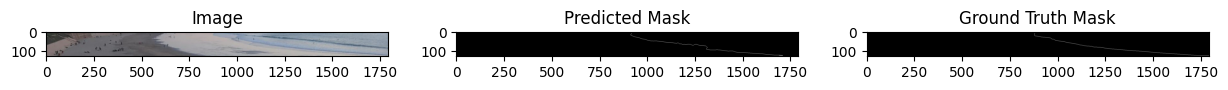

Mean error (Pred->Gt):  5.932018969745522
Mean error (Gt->Pred):  9.842303045216504


In [13]:
index = 120
print("Image path: ", data["test"]["images"][index])
# mask = cv2.imread(data["test"]["predicted_mask"][index], cv2.IMREAD_GRAYSCALE)
# plt.imshow(mask, cmap='gray')
# plt.show()
# print(np.unique(mask))

mask_pred = obtain_shoreline.transform_mask_to_shoreline(pred_path = data["test"]["predicted_mask"][index], landward=0, seaward=1)
mask_gt = obtain_shoreline.transform_mask_to_shoreline(pred_path = data["test"]["ground_truth"][index], landward=0, seaward=1)

# # Plot in the same figure
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
img = cv2.imread(data["test"]["images"][index])
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.title("Image")
plt.subplot(1, 3, 2)
plt.imshow(mask_pred, cmap='gray')
plt.title("Predicted Mask")
plt.subplot(1, 3, 3)
plt.imshow(mask_gt, cmap='gray')
plt.title("Ground Truth Mask")
plt.show()

dists_pred_to_gt, dists_gt_to_pred = compute_distance(mask_pred, mask_gt)

mean_error = np.mean(dists_pred_to_gt)
print("Mean error (Pred->Gt): ", mean_error)

mean_error = np.mean(dists_gt_to_pred)
print("Mean error (Gt->Pred): ", mean_error)


In [15]:
import numpy as np
import cv2

dist_pred_to_gt_global = []
dist_gt_to_pred_global = []
pred_points = 0
gt_points = 0
# distances_per_image = []

coasts = ["agrelo", "cies", "cadiz", "samarador", "arenaldentem"]
global_distance_all_ponts = {}

for coast in coasts:
    global_distance_all_ponts[coast] = {
        "dist_pred_to_gt": [],
        "dist_gt_to_pred": [],
        "pred_points": 0,
        "gt_points": 0
    }

for index in range(len(data["test"]["predicted_mask"])):
    mask_pred = obtain_shoreline.transform_mask_to_shoreline(pred_path = data["test"]["predicted_mask"][index], landward=0, seaward=1)
    mask_gt = obtain_shoreline.transform_mask_to_shoreline(pred_path = data["test"]["ground_truth"][index], landward=0, seaward=1)

    dists_pred_to_gt, dist_gt_to_pred = compute_distance(mask_pred=mask_pred, mask_gt=mask_gt)
    if len(dists_pred_to_gt) == 0:
        print(f"Skipping image {index} due to no points in either predicted or ground truth mask.")
        gt_points += len(dist_gt_to_pred)
        continue

    dist_pred_to_gt_global.extend(dists_pred_to_gt)
    dist_gt_to_pred_global.extend(dist_gt_to_pred)
    pred_points += len(dists_pred_to_gt)
    gt_points += len(dist_gt_to_pred)

    for coast in coasts:
        if coast in data["test"]["predicted_mask"][index]:
            global_distance_all_ponts[coast]['dist_pred_to_gt'].extend(dists_pred_to_gt)
            global_distance_all_ponts[coast]['dist_gt_to_pred'].extend(dist_gt_to_pred)
            global_distance_all_ponts[coast]['pred_points'] += len(dists_pred_to_gt)
            global_distance_all_ponts[coast]['gt_points'] += len(dist_gt_to_pred)
            # global_distance_per_image[coast].append(np.mean(dists_pred_to_gt))

print(f"Number of points pred: {pred_points}, gt: {gt_points}, ratio: {pred_points/gt_points:.2f}")
print(f"Mean Absolute Distance (pred->Gt) global: {np.mean(dist_pred_to_gt_global):.4f} +/- {np.std(dist_pred_to_gt_global):.4f}")
print(f"Mean Absolute Distance (Gt->pred) global: {np.mean(dist_gt_to_pred_global):.4f} +/- {np.std(dist_gt_to_pred_global):.4f}")
print(f"RMSD Distance (pred->Gt) global: {np.sqrt(np.mean(np.square(dist_pred_to_gt_global))):.4f}")
print(f"RMSD Distance (Gt->pred) global: {np.sqrt(np.mean(np.square(dist_gt_to_pred_global))):.4f}")
print(f"Q3 (75th percentile) (pred->Gt) global: {np.percentile(dist_pred_to_gt_global, 75):.4f}")
print(f"Q3 (75th percentile) (Gt->pred) global: {np.percentile(dist_gt_to_pred_global, 75):.4f}")

for coast in coasts:
    print("\nCoast: ", coast)
    mean_all_pred_to_gt = np.mean(global_distance_all_ponts[coast]['dist_pred_to_gt'])
    std_all_pred_to_gt = np.std(global_distance_all_ponts[coast]['dist_pred_to_gt'])
    mean_all_gt_to_pred = np.mean(global_distance_all_ponts[coast]['dist_gt_to_pred'])
    std_all_gt_to_pred = np.std(global_distance_all_ponts[coast]['dist_gt_to_pred'])
    rmsd_all_pred_to_gt = np.sqrt(np.mean(np.square(global_distance_all_ponts[coast]['dist_pred_to_gt'])))
    rmsd_all_gt_to_pred = np.sqrt(np.mean(np.square(global_distance_all_ponts[coast]['dist_gt_to_pred'])))

    q3_pred_to_gt = np.percentile(global_distance_all_ponts[coast]['dist_pred_to_gt'], 75)
    q3_gt_to_pred = np.percentile(global_distance_all_ponts[coast]['dist_gt_to_pred'], 75)

    print(f"Number of points pred: {global_distance_all_ponts[coast]['pred_points']}, gt: {global_distance_all_ponts[coast]['gt_points']}, ratio: {global_distance_all_ponts[coast]['pred_points']/global_distance_all_ponts[coast]['gt_points']:.2f}")
    print(f"Mean Absolute Distance (pred->Gt) for {coast}: {mean_all_pred_to_gt:.4f} +/- {std_all_pred_to_gt:.4f}")
    print(f"Mean Absolute Distance (Gt->pred) for {coast}: {mean_all_gt_to_pred:.4f} +/- {std_all_gt_to_pred:.4f}")
    print(f"RMSD Distance (pred->Gt) for {coast}: {rmsd_all_pred_to_gt:.4f}")
    print(f"RMSD Distance (Gt->pred) for {coast}: {rmsd_all_gt_to_pred:.4f}")
    print(f"Q3 (75th percentile) (pred->Gt) for {coast}: {q3_pred_to_gt:.4f}")
    print(f"Q3 (75th percentile) (Gt->pred) for {coast}: {q3_gt_to_pred:.4f}")


Number of points pred: 362761, gt: 337923, ratio: 1.07
Mean Absolute Distance (pred->Gt) global: 48.6226 +/- 210.8399
Mean Absolute Distance (Gt->pred) global: 29.7599 +/- 118.8845
RMSD Distance (pred->Gt) global: 216.3738
RMSD Distance (Gt->pred) global: 122.5527
percentage of points within 3 m (pred->Gt) global: 31.76%
percentage of points within 3 m (Gt->pred) global: 34.00%
Q3 (75th percentile) (pred->Gt) global: 17.6918
Q3 (75th percentile) (Gt->pred) global: 13.9284

Coast:  agrelo
Number of points pred: 113331, gt: 98443, ratio: 1.15
Mean Absolute Distance (pred->Gt) for agrelo: 122.2924 +/- 364.5651
Mean Absolute Distance (Gt->pred) for agrelo: 55.6728 +/- 192.8384
RMSD Distance (pred->Gt) for agrelo: 384.5297
RMSD Distance (Gt->pred) for agrelo: 200.7140
Q3 (75th percentile) (pred->Gt) for agrelo: 26.8328
Q3 (75th percentile) (Gt->pred) for agrelo: 17.0000

Coast:  cies
Number of points pred: 99438, gt: 88766, ratio: 1.12
Mean Absolute Distance (pred->Gt) for cies: 13.2879 +/-